<a href="https://colab.research.google.com/github/jhambale/Ab_display_flow_cytometry_stats/blob/main/Hills_equation_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import ast
import pysam
from Bio import SeqIO
import glob
import math
import numpy as np
from itertools import combinations
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import os
from dnds import dnds, pnps
import scipy.stats as stats
from scipy.stats import shapiro
from scipy.optimize import curve_fit
import re

from utils import *
import argparse


Analyzing: r3
------------------------------------------------------------
→ Model: hyperbolic with background
  Bmax = 606836043.214
  Kd = 43564118498.672 nM
  Background = 57.414
  R² = 0.8856

Analyzing: r4
------------------------------------------------------------
→ Model: hyperbolic with background
  Bmax = 35463950.411
  Kd = 3324286157.765 nM
  Background = 59.819
  R² = 0.9607

Analyzing: r2
------------------------------------------------------------
→ Model: hyperbolic with background
  Bmax = 107087985.628
  Kd = 10817397587.578 nM
  Background = 59.345
  R² = 0.7129

Analyzing: r6
------------------------------------------------------------
→ Model: hyperbolic with background
  Bmax = 72.811
  Kd = 7490.311 nM
  Background = 61.610
  R² = 0.8585

Analyzing: r7
------------------------------------------------------------
→ Model: hyperbolic with background
  Bmax = 167307940.389
  Kd = 18651793399.334 nM
  Background = 56.154
  R² = 0.8147

Analyzing: r1
----------------

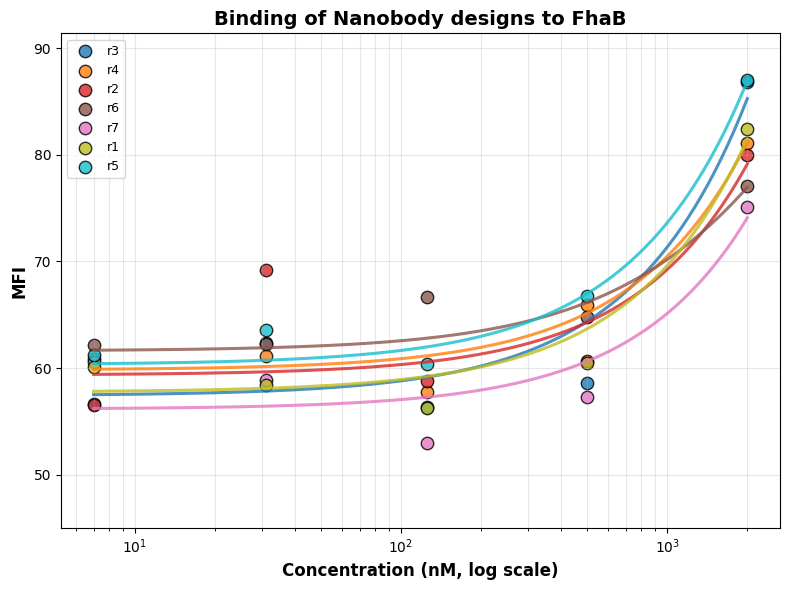

In [ ]:
''' hyperbolic is same as hill, but with n=1 '''
''' the equation I used is with background, since we have some baseline fluoroscence which is captured as the binding-sticky MFI at 0 antigen concentration '''


# ---------------------------
# Binding equations
# ---------------------------

def hill_equation(L, Bmax, Kd, n):
    """Hill equation (no background)."""
    return Bmax * np.power(L, n) / (np.power(Kd, n) + np.power(L, n))

def hyperbolic_binding(L, Bmax, Kd):
    """Hyperbolic binding (no background)."""
    return Bmax * L / (Kd + L)

def hill_equation_with_bg(L, Bmax, Kd, n, Background):
    """Hill equation with background term."""
    return Background + Bmax * np.power(L, n) / (np.power(Kd, n) + np.power(L, n))

def hyperbolic_binding_with_bg(L, Bmax, Kd, Background):
    """Hyperbolic binding with background term."""
    return Background + Bmax * L / (Kd + L)


# ---------------------------
# Curve fitting function
# ---------------------------


def fit_binding_curve(concentrations, binding_values, model='hill', allow_background=True):
    """
    Fit binding data to a model (Hill or Hyperbolic), optionally fitting a background term.
    """
    max_binding = np.max(binding_values)
    min_binding = np.min(binding_values)
    half_max = (max_binding + min_binding) / 2

    idx_half = np.argmin(np.abs(binding_values - half_max))
    Kd_guess = concentrations[idx_half] if concentrations[idx_half] > 0 else np.median(concentrations[concentrations > 0])
    Background_guess = np.mean(binding_values[concentrations == 0]) if np.any(concentrations == 0) else min_binding

    baseline_offset = abs(Background_guess)
    fit_background = allow_background and baseline_offset > 0.05 * max_binding

    if model == 'hill':
        if fit_background:
            p0 = [max_binding - Background_guess, Kd_guess, 1.0, Background_guess]
            bounds = ([0, 0, 0.1, -np.inf], [np.inf, np.inf, 5, np.inf])
            fit_func = hill_equation_with_bg
        else:
            p0 = [max_binding, Kd_guess, 1.0]
            bounds = ([0, 0, 0.1], [np.inf, np.inf, 5])
            fit_func = hill_equation
    else:
        if fit_background:
            p0 = [max_binding - Background_guess, Kd_guess, Background_guess]
            bounds = ([0, 0, -np.inf], [np.inf, np.inf, np.inf])
            fit_func = hyperbolic_binding_with_bg
        else:
            p0 = [max_binding, Kd_guess]
            bounds = ([0, 0], [np.inf, np.inf])
            fit_func = hyperbolic_binding

    try:
        params, pcov = curve_fit(fit_func, concentrations, binding_values,
                                 p0=p0, bounds=bounds, maxfev=10000)
        fitted_values = fit_func(concentrations, *params)
        ss_res = np.sum((binding_values - fitted_values) ** 2)
        ss_tot = np.sum((binding_values - np.mean(binding_values)) ** 2)
        r_squared = 1 - (ss_res / ss_tot)
        return params, pcov, r_squared, fit_func
    except Exception as e:
        print(f"⚠ Fit failed: {e}")
        return None, None, None, None


# ---------------------------
# Plotting function
# ---------------------------

def plot_binding_curves(df, cell_names=None, model='hill', combined=True):
    if cell_names is None:
        cell_names = df['cell_name'].unique()

    colors = plt.cm.tab10(np.linspace(0, 1, len(cell_names)))

    if combined:
        plt.figure(figsize=(8, 6))
        ax = plt.gca()
    else:
        fig, axes = plt.subplots(len(cell_names), 1, figsize=(8, 5 * len(cell_names)))
        if len(cell_names) == 1:
            axes = [axes]

    for idx, cell_name in enumerate(cell_names):
        cell_data = df[df['cell_name'] == cell_name].sort_values('concentration_nM')
        conc = cell_data['concentration_nM'].values
        binding = cell_data['binding_minus_sticky'].values

        print(f"\n{'='*60}")
        print(f"Analyzing: {cell_name}")
        print(f"{'-'*60}")

        params, pcov, r2, fit_func = fit_binding_curve(conc, binding, model=model)
        if params is None:
            print("Fit failed — skipping this sample.")
            continue

        fit_name = fit_func.__name__
        has_bg = 'with_bg' in fit_name
        print(f"→ Model: {model} {'with background' if has_bg else '(no background)'}")

        conc_smooth = np.logspace(np.log10(max(conc[conc > 0].min(), 0.001)),
                                  np.log10(conc.max()), 200)
        binding_fit = fit_func(conc_smooth, *params)

        if combined:
            ax_here = ax
        else:
            ax_here = axes[idx]

        # Plot data points (keep in legend)
        ax_here.scatter(conc, binding, s=80, alpha=0.8,
                        edgecolor='black', color=colors[idx],
                        label=f'{cell_name}')

        # Plot fitted curve (no label)
        ax_here.plot(conc_smooth, binding_fit, '-', linewidth=2.2,
                     color=colors[idx], alpha=0.8)

        # Print fitted parameters
        if model == 'hill':
            if has_bg:
                Bmax, Kd, n, Background = params
                print(f"  Bmax = {Bmax:.3f}")
                print(f"  Kd = {Kd:.3f} nM")
                print(f"  n (Hill) = {n:.3f}")
                print(f"  Background = {Background:.3f}")
            else:
                Bmax, Kd, n = params
                print(f"  Bmax = {Bmax:.3f}")
                print(f"  Kd = {Kd:.3f} nM")
                print(f"  n (Hill) = {n:.3f}")
        else:
            if has_bg:
                Bmax, Kd, Background = params
                print(f"  Bmax = {Bmax:.3f}")
                print(f"  Kd = {Kd:.3f} nM")
                print(f"  Background = {Background:.3f}")
            else:
                Bmax, Kd = params
                print(f"  Bmax = {Bmax:.3f}")
                print(f"  Kd = {Kd:.3f} nM")

        print(f"  R² = {r2:.4f}")

    # Finalize plot
    if combined:
        ax.axhline(y=0, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
        ax.set_xscale('log')
        ax.set_ylim(bottom=45)  # <-- Y-axis starts at 45
        ax.set_xlabel('Concentration (nM, log scale)', fontsize=12, fontweight='bold')
        ax.set_ylabel('MFI', fontsize=12, fontweight='bold')
        ax.set_title('Binding of Nanobody designs to FhaB', fontsize=14, fontweight='bold')
        ax.legend(fontsize=9, loc='best')
        ax.grid(True, which='both', alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        for ax_here in axes:
            ax_here.axhline(y=0, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
            ax_here.set_xscale('log')
            ax_here.set_ylim(bottom=45)
            ax_here.set_xlabel('Concentration (nM, log scale)', fontsize=12, fontweight='bold')
            ax_here.set_ylabel('Binding (MFI)', fontsize=12, fontweight='bold')
            ax_here.legend(fontsize=9, loc='best')
            ax_here.grid(True, which='both', alpha=0.3)
        plt.tight_layout()
        plt.show()


# Run plot
plot_binding_curves(sample_binding_df, model='hyperbolic', combined=True)
